# Probabilistic Occupancy Grid Map
---

*Narcís Palomeras - September 2022 - Universitat de Girona (all rights reserved)*

In this lab you are going to implement a 2D probabilistic occupancy grid map. Thge main idea is to combine robot poses and range measurements to create a map of free, occupied and unknown regions. We are going to assume that robot pose is known by some other method and, therefore, it is drift free.

The following elements are provided:

* `ground_truth_02.csv` file: contains the robot position at each time stamp.
* `laser_scan_02.csv` file: contains all range measurements gathered by the robot.
* `load_csv_files.py`: includes several auxiliar functions to load the `CSV` data as well as a `wrap_angle` function to normalize angles between $-\pi$ and $\pi$.


**Exercise 1:**

To familiarize yourself with the previous files do:

* load the data from `ground_truth_02.csv` and `laser_scan_02.csv` and check the format of the returned structures.
* plot the ground truth trajectory. 
* test the `bresenham` library ploting a line between $[-3, 5]$ to $[4, -2]$.

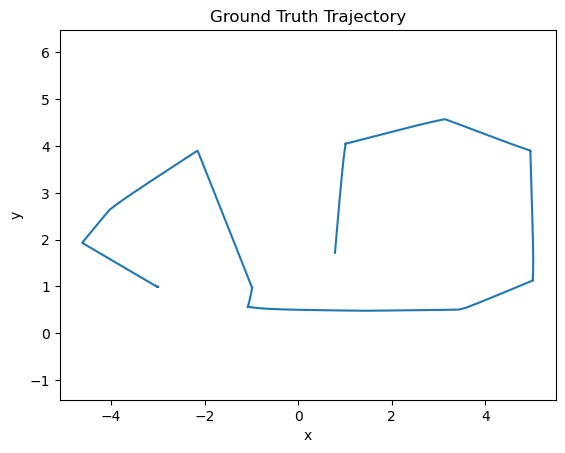

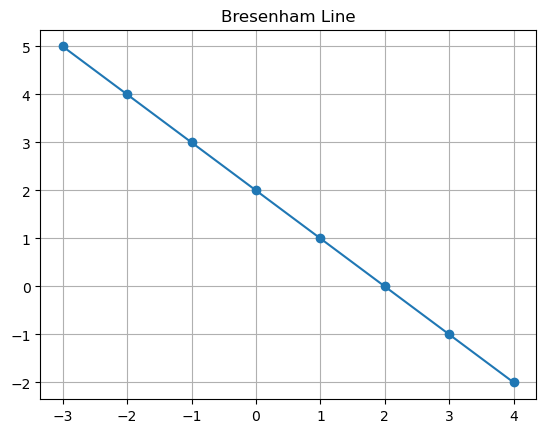

In [12]:
import numpy as np
from matplotlib import pyplot as plt
from bresenham import bresenham # pip install bresenham if required
from load_csv_files import load_encoders, load_laser_scans, load_ground_truth, wrap_angle

# LOAD DATASETS
laser_scans = load_laser_scans('laser_scan_02.csv')
stamped_gt = load_ground_truth('ground_truth_02.csv')

# Plot stamped_gt trajectory

plt.figure
plt.plot([gt[1] for gt in stamped_gt], [gt[2] for gt in stamped_gt])
plt.title('Ground Truth Trajectory')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

# Plot bresenham line between [-3, 5] and [4, -2] using the bresenham function from bresenham library 
# WARNING! bresenham function returns a generator, so you need to convert it to a list to use it:
# points = list(bresenham(x1, y1, x2, y2))
points = list(bresenham(-3, 5, 4, -2))
plt.figure
plt.plot([p[0] for p in points], [p[1] for p in points], 'o-')
plt.title('Bresenham Line')
plt.grid(True)

plt.show()

To create a gridmap several functions and data structures are required. We have groupped them in a single class called `GridMap`. 

**Exercise 2:**

Complete the following `GridMap` class following the comments.

In [13]:
import numpy as np
from bresenham import bresenham


class GridMap:
    """
    Probabilistic occupancy grid map. 
    """
    
    # Maximum and minimum cell loggoods (is equivalen to p_max = 0.999, p_min = 0.001)
    LMAX = 6.91 
    LMIN = -6.91

    # Initialize gridmap class
    def __init__(self, center, cell_size=0.1, map_size=10):
        self.cell_size = cell_size
        self.grid = np.zeros((int(map_size/cell_size), int(map_size/cell_size)))
        self.origin = np.array(center) - np.array([map_size, map_size])/2

    # return map
    def get_map(self):
        return self.grid

    # return origin
    def get_origin(self):
        return self.origin
    
    # Transform position wrt frame origin to cell indexes
    def __position_to_cell__(self, position):
        cell = ((np.array(position) - self.origin) / self.cell_size).astype(int)
        return cell

    # Update cell uv with probability p
    def __update_cell__(self, uv, p):
        # Check that probability p is between 0 and 1 but not 0 or 1
        if p <= 0 or p >=1:
            return

        # Compute inverse sensor model
        l = np.log(p / (1 - p))

        # Update cell and saturate between GridMap.LMIN and GridMap.LMAX 
        u, v = uv
        if 0 <= u < self.grid.shape[0] and 0 <= v < self.grid.shape[1]:
            self.grid[u][v] = np.clip(self.grid[u][v] + l, GridMap.LMIN, GridMap.LMAX)

    # Update all cells traversed by a ray
    def add_ray(self, ray_init_position, ray_angle, ray_range, p):
        # Compute ray final position using ray start, angle and range
        ray_end_position = [
            ray_init_position[0] + ray_range * np.cos(ray_angle),
            ray_init_position[1] + ray_range * np.sin(ray_angle)
        ]

        # Transform intial and final position to cell indexes
        cell_start = self.__position_to_cell__(ray_init_position)
        cell_end = self.__position_to_cell__(ray_end_position)

        # Use Bresenham's algorithm to get traversed cells
        cells = list(bresenham(cell_start[0], cell_start[1], cell_end[0], cell_end[1]))


        # Update as no occupied (probability 1-p) the cells between start and end - 1 
        for cell in cells[:-1]:
            self.__update_cell__(cell, 1 - p)
            
        # and the last cell with probability p
        self.__update_cell__(cells[-1], p)


## Dataset preparation

To create a gridmap from the robot poses and ranges it is required to have both data synchronized. 

**Exercise 3:**

Filter the `stamped_gt` data in order to have only robot positions in the time stamps in which a scan is gathered. Save the filtered poses to the `state` list. 

### pseudocode:
```
Initialize an empty list "state"
Set "i" to 0
For each "m" in "laser_scans" do
    While the first element of "stamped_gt" at index "i" is less than the first element of "m" do
        Increment "i" by 1
    End While
    Append the element at index "i" of "stamped_gt" to "state"
End For
Get the length of "state"```

In [14]:
state = []
# Filter `stamped_gt` data to have the same dimension of `laser_scans` and be synchronized with it
i = 0
for m in laser_scans:
    while stamped_gt[i][0] < m[0]:
        i += 1
    state.append(stamped_gt[i])
len(state)

1506

In [15]:
print(type(laser_scans[0]))
print(len(laser_scans[0]))
print(laser_scans[0])

<class 'tuple'>
3
(330.032, [2.932579517364502, 2.938606023788452, 2.954451560974121, 2.9446372985839844, 2.9458959102630615, 2.9441614151000977, 2.9537343978881836, 2.9540889263153076, 2.9637768268585205, 2.985379695892334, 2.972987174987793, 2.998208999633789, 3.002493143081665, 3.006049633026123, 3.023702383041382, 3.0463616847991943, 3.052410364151001, 3.0760180950164795, 3.075169801712036, 3.0971713066101074, 3.130897045135498, 3.1544148921966553, 3.1814396381378174, 3.2065582275390625, 3.2311594486236572, 3.2741453647613525, 3.275754690170288, 3.3172712326049805, 3.331390619277954, 3.369852304458618, 3.4092135429382324, 3.434854507446289, 3.4751148223876953, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, 1.503869652748108, 1.486695408821106, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, 2.1010818481445312, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,

In [16]:
print(type(state[0]))
print(len(state[0]))
print(state[0])

<class 'numpy.ndarray'>
4
[ 3.30032000e+02 -2.99993510e+00  1.00019343e+00  1.21358411e-03]


## Building the Probabilistic Grid Map

Now that all data is loaded and synchronized and that the `GridMap` class is ready is time to build the probabilistic grid map.

**Exercise 4:**

For each scan in the `laser_scans` list add each one of its rays in the gridmap using the `add_ray` method. You need to provide the robot position, where it gathered this beam, and the beam orientation. Be aware that the beam orientation is the composition of the robot orientation and the beam *theta*.

> Note 1: use only ranges that its value is between `min_range` and `max_range`

> Note 2: This process is quite large. Start testing with only few scans and, when it works, try with the full dataset.

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


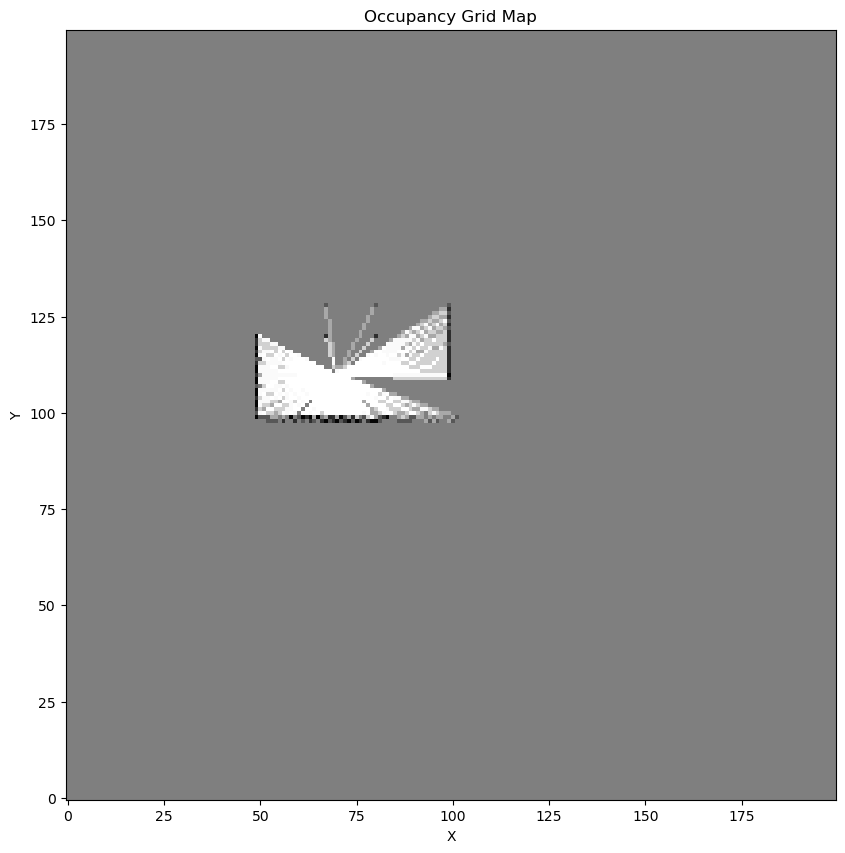

In [ ]:
# Initialize data
min_range = 0.1
max_range = 5.0
gridmap = GridMap(np.array([0, 0]), 0.1, 20)

# for each scan in `laser_scans`
# test for only frist scan
for idx, scan in enumerate(laser_scans[0:1]):
    timestamp = scan[0]
    ranges = scan[1] 
    angles = scan[2]

    # Robot pose from state
    robot_x = state[idx][1]
    robot_y = state[idx][2]
    robot_theta = state[idx][3]

    # for each beam in scan
    for i, r in enumerate(ranges):
        # if beam range is between min_range and max_range
        if min_range < r < max_range:
            # compute ray angle (robot orientation + beam angle)
            ray_angle = robot_theta + angles[i]
            
            # add ray to gridmap
            gridmap.add_ray([robot_x, robot_y], ray_angle, r, 0.9)
# Plot the resulting gridmap
plt.figure(figsize=(10, 10))
plt.imshow(gridmap.get_map().T, cmap='gray_r', origin='lower')

plt.title('Occupancy Grid Map')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

# Save as a PNG image
plt.imsave('gridmap.png', gridmap.get_map().T, cmap='gray_r', origin='lower')

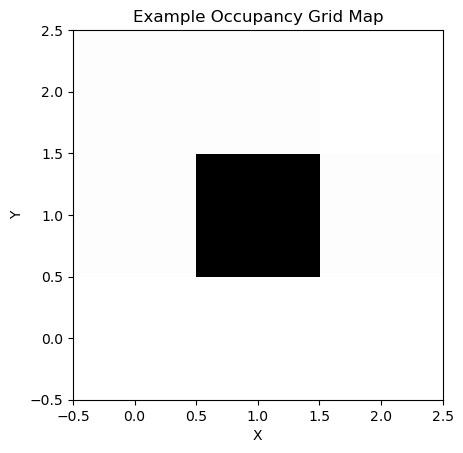

In [24]:
# example for map publishing in ROS, using OccupancyGrid message type
ex_map = np.array([[-1, -1, -1], [0, 100, 0], [0, 0, -1]]) # Example occupancy grid map
ex_map = np.clip(ex_map, -1, 100) # Ensure values are between -1 and 100
# plot example map
plt.figure
plt.imshow(ex_map, cmap='gray_r', origin='lower')
plt.title('Example Occupancy Grid Map')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()